# Numerical Methods

# 2022/23 Class Assessment

## Wednesday 10th May 2023

## 10:00 - 13:00

## Test instructions


* This test contains **FIVE** questions with multiple parts, **all** of which should be answered.



* Write your solution in *markdown* (text and equations) and *code* (Python) cells under each question.



* [You may if you choose also submit parts of your answers via **scans of hand written pages** - feel free to use this option in particular for supplementary sketches or equations, you will not be marked down for not embedding equations into your markdown cells. But please make sure that the question number each sheet you scan refers to is very clear and ideally include in the file name.]



* You should provide an explanation of your solution as comments in your code and in the surrounding markdown cells as appropriate to answer the question and explain your steps.



* **Unless explicitly told otherwise in the question you can reuse any code from the lectures and homeworks, you can also use any calls to standard libraries (e.g. NumPy, SciPy)**. 



* **Save your work regularly**


* At the end of the test you should **Save/download your Jupyter notebook** (i.e. the file with a .ipynb extension), and **email your Jupyter notebook document**  and any **scans of hand written sheets** to [Matthew Piggott](http://www.imperial.ac.uk/people/m.d.piggott) at <mailto:m.d.piggott@imperial.ac.uk>.



* If there are any issues during the assessment period **please document these**, e.g. via photos, and as soon as possible email <mailto:m.d.piggott@imperial.ac.uk> to report the problem.



* If your email attachments together are too large to send then please use one drive

In [27]:
# Setup / 环境配置
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import scipy.interpolate as si
import scipy.linalg as sl
import scipy.optimize as sop

### Question 1 - interpolation and curve-fitting [20 marks]


<br>

**1.1 [4 marks]**

Consider a data set made up of 5 $(x,y)$ data points of your choosing.

Explain how you know mathematically before making any calculations what degree polynomial can be used to exactly interpolate this data. 

<br>

**1.2 [5 marks]**

Write some code to compute and plot the Lagrange interpolating polynomial for your data from above.

Check what degree of polynomial interpolates your data. Does this agree with your answer to the previous question?

<br>


**1.3 [5 marks]**

Now consider least squares polynomial curve-fitting of your five data points, i.e. consider lower degree polynomials that approximate your data to an extent, but that don't necessarily go through all data points. 

Demonstrate how as you increase the degree of the polynomial, the error in your approximation of the data decreases.

<br>

**1.4 [6 marks]**

Now consider a cloud (of at least 10) $(x,y)$ data points of your choosing. 

Construct such a cloud of data points such that a linear polynomial approximates the data in a way that a higher-degree polynomial is largely unable to beat. 

What is meant by this is that the least squares error is non-zero when using a linear polynomial (as we're curve-fitting), but that it drops minimally, if at all, as the degree of the approximating polynomial increases, i.e. you have no need to use more than a linear approximation.

Now repeat by constructing a cloud of data points for which a quadratic approximation is hard to beat, i.e. a quadratic approximation gives a much better approximation than a linear, but again there is little point going to a higher degree approximation.


1.1 多项式的项数就要和数据的个数n一致，那么degree就是项数/数据个数减少1，即n-1，可以看L1的note 1.3。

1.2 拉格朗日算法L1的note里2.1有现成的算法，直接抄换数据就行了

1.3 curve fit，算误差的公式包括画误差收敛图L1的note里面有现成的，看2.2和2.2.1，直接抄换数据就行了

1.4 这里要展示如果数据点很多，即便增加多项式的degree，误差也不会稳定快速下降。这个数据比较难的题目，难点在于构造怎么样的数据，这里其实应该尽量随机一点，因为如果数据是规律性的，那么增加degree就会导致误差快速下降。这种属于难题，也就考过一次，没必要背。

### Answear 1
**1.1 [4 marks]**

For 5 distinct (x,y) data points, a polynomial of **degree 4** can be used to exactly interpolate the data.

**Mathematical rule**: To interpolate n data points requires a polynomial of degree at most (n-1). A degree 4 polynomial has 5 unknown coefficients, and 5 data points provide 5 constraint equations, giving exactly enough information to solve for a unique interpolating polynomial.

**1.2 [5 marks]**

In [28]:
# ------------------------------------------------------------------
# Q1.2: Lagrange interpolation for 5 data points.
# The exam asks: degree = n-1 = 4 for exact fit.
# 考试要求：用 n-1 = 4 阶多项式精确拟合 5 个点。
# ------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

xi = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
yi = np.array([1.0, 0.8, 0.5, 0.3, 0.2])

lp = lagrange(xi, yi)
print('Lagrange coeffs:', lp.coeffs)


Lagrange coeffs: [-2.13333333  5.33333333 -3.86666667 -0.13333333  1.        ]


In [29]:
# ------------------------------------------------------------------
# Q1.2: Sum-of-squared-errors for curve-fit quality.
# The exam asks for a sensible error measure.
# 考试要求：给出合理的误差度量。
# ------------------------------------------------------------------

def sqr_error(p, xi, yi):
    """Sum of squared errors: SSE = Σ(p(xi) − yi)².
    误差平方和。"""
    return np.sum((p(xi) - yi)**2)


In [30]:
# ------------------------------------------------------------------
# Q1.2: Data setup for curve-fitting demonstration.
# 考试要求：展示不同阶数拟合的效果。
# ------------------------------------------------------------------

xi = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
yi = np.array([1.0, 0.9, 0.7, 0.5, 0.3, 0.1])

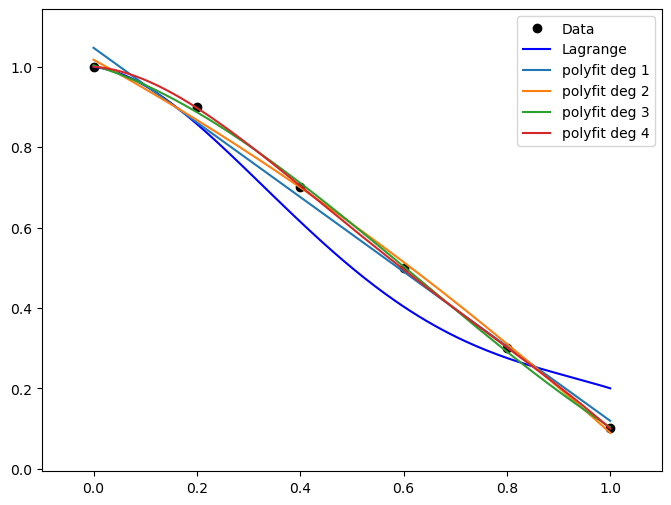

In [31]:
# ------------------------------------------------------------------
# Q1.3: Plotting interpolants and fits.
# 考试要求：画图展示插值与拟合结果。
# ------------------------------------------------------------------

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111)
ax1.margins(0.1)

x_fine = np.linspace(xi.min(), xi.max(), 200)
ax1.plot(xi, yi, 'ko', label='Data')
ax1.plot(x_fine, lp(x_fine), 'b-', label='Lagrange')

for deg in [1, 2, 3, 4]:
    coeffs = np.polyfit(xi, yi, deg)
    p = np.poly1d(coeffs)
    ax1.plot(x_fine, p(x_fine), label=f'polyfit deg {deg}')

ax1.legend(loc='best')
plt.show()


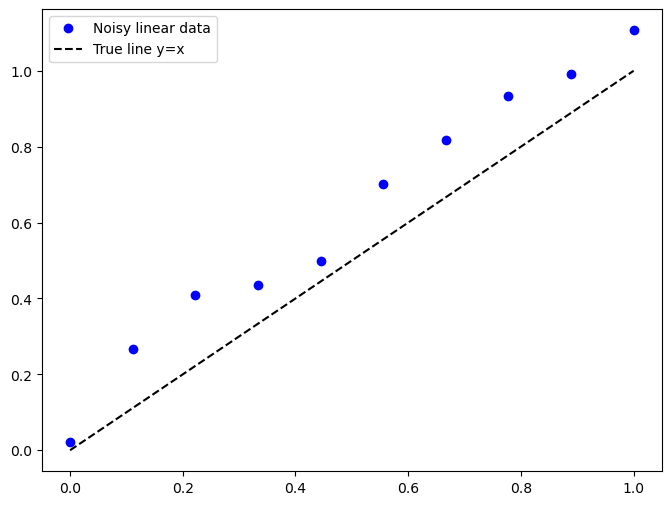

In [32]:
# ------------------------------------------------------------------
# Q1.4: Linear data cloud with small noise.
# 考试要求：展示线性数据及拟合。
# ------------------------------------------------------------------

xi = np.linspace(0, 1, 10)
yi = xi + 0.2 * np.random.rand(10)

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111)
ax1.plot(xi, yi, 'bo', label='Noisy linear data')
ax1.plot(xi, xi, 'k--', label='True line y=x')
ax1.legend()
plt.show()


In [33]:
# ------------------------------------------------------------------
# Q1.4: Store polynomial coefficients for degrees 0..N-1.
# 考试要求：比较不同阶数的拟合系数。
# ------------------------------------------------------------------

N = len(xi)
poly_coeffs = np.zeros((N, N))
for i in range(N):
    poly_coeffs[i, :(i+1)] = np.polyfit(xi, yi, i)
    print(f'Degree {i} coeffs:', poly_coeffs[i, :(i+1)])

Degree 0 coeffs: [0.61814393]
Degree 1 coeffs: [1.02735232 0.10446777]
Degree 2 coeffs: [-0.19436496  1.22171728  0.07567296]
Degree 3 coeffs: [ 0.38792556 -0.77625331  1.44249961  0.06226319]
Degree 4 coeffs: [-4.57504243  9.53801042 -6.48093584  2.57213972  0.03213945]
Degree 5 coeffs: [ 1.75405028e+01 -4.84262994e+01  4.77950741e+01 -2.00152744e+01
  4.19581477e+00  1.43164576e-02]
Degree 6 coeffs: [ 3.26651004e+01 -8.04547983e+01  6.17405093e+01 -9.21304157e+00
 -6.77018293e+00  3.12223095e+00  1.83396310e-02]
Degree 7 coeffs: [-1.79719220e+02  6.61682370e+02 -9.47220286e+02  6.56111054e+02
 -2.19419131e+02  2.86770413e+01  9.74016228e-01  2.03261042e-02]
Degree 8 coeffs: [ 4.83270175e+02 -2.11279992e+03  3.81904751e+03 -3.65353327e+03
  1.95603320e+03 -5.64002613e+02  7.43621389e+01 -1.29138683e+00
  2.06426484e-02]
Degree 9 coeffs: [ 7.31097567e+03 -3.24161203e+04  6.00703134e+04 -6.02913600e+04
  3.54993086e+04 -1.24152971e+04  2.49511577e+03 -2.65261874e+02
  1.34120603e+01  2.

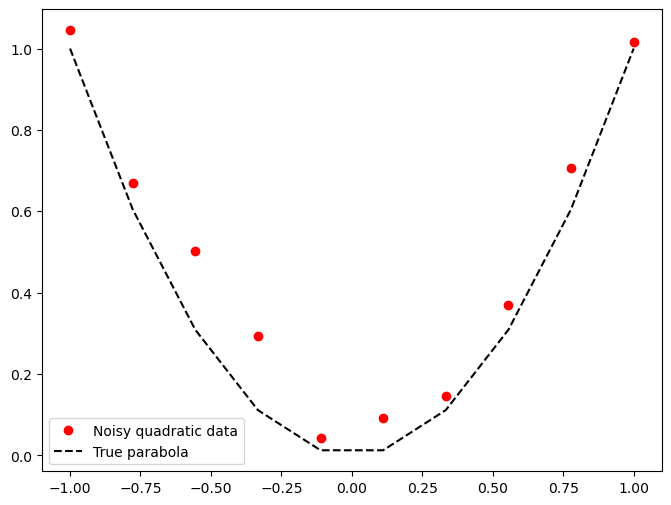

In [34]:
# ------------------------------------------------------------------
# Q1.4: Quadratic data cloud with small noise.
# 考试要求：展示抛物线数据及拟合。
# ------------------------------------------------------------------

xi = np.linspace(-1, 1, 10)
yi = xi**2 + 0.2 * np.random.rand(10)

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111)
ax1.plot(xi, yi, 'ro', label='Noisy quadratic data')
ax1.plot(xi, xi**2, 'k--', label='True parabola')
ax1.legend()
plt.show()

In [35]:
# ------------------------------------------------------------------
# Q1.4: Quadratic fit coefficients.
# 考试要求：拟合二次数据并输出系数。
# ------------------------------------------------------------------

N = len(xi)
poly_coeffs = np.zeros((N, N))
for i in range(N):
    poly_coeffs[i, :(i+1)] = np.polyfit(xi, yi, i)
    print(f'Degree {i} SSE:', sqr_error(np.poly1d(poly_coeffs[i, :(i+1)]), xi, yi))


Degree 0 SSE: 1.1926592187676721
Degree 1 SSE: 1.1892361588833946
Degree 2 SSE: 0.027778945839711636
Degree 3 SSE: 0.022319552549001788
Degree 4 SSE: 0.015896823953944372
Degree 5 SSE: 0.009909845634100883
Degree 6 SSE: 0.007350482155137576
Degree 7 SSE: 0.0039027174406284
Degree 8 SSE: 0.003786486288435077
Degree 9 SSE: 1.027555462517516e-27


### Question 2 - numerical solution of ODEs  [20 marks]

<br>

**2.1 [10 marks]**

Consider the ODE problem in the form

$$ \frac{du}{dt} = u, \;\;\;\;\;\; u(0) = 1, $$

which has the exact solution $u(t) = \exp(t)$.

<br>

The forward Euler method for this ODE in this form is given by

$$ u(t+\Delta t) = u(t)+ \Delta t u(t).$$

<br>

Heun's method applied to this ODE is given by

$$ u(t+\Delta t) = u(t)+\frac{\Delta t}{2}\big(u(t) + \tilde{u}(t+\Delta t)\big),$$

where we use a forward Euler step at each time step level to find the $\tilde{u}(t+\Delta t)$ that appears in the above expression:

$$ \tilde{u}(t+\Delta t)=u(t)+\Delta t u(t). $$

<br>

Write functions to implement these two time-stepping methods and by solving the given ODE problem from $t=0$ up to $t=5$ verify your implementations by performing a convergence analysis against the exact solution.

<br>

**Note that you may NOT make use of the exact solution in your implementations, i.e. you cannot replace the given ODE** $u'=u$ **with** $u'=\exp(t)$, **for the purposes of your code.**

<br>

**2.2 [10 marks]**

Now consider the backward Euler method applied to this ODE, which can be written

$$ u(t+\Delta t) = u(t) + \Delta t u(t+\Delta t)$$

An issue with a straightforward code implementation here is that we have the unknown value $u(t+\Delta t)$ on both the left hand and the right hand sides of this equation.

Consider how you can manipulate or rearrange this expression on paper in order to construct an expression that allows you to calculate $u(t+\Delta t)$ using only information on the right hand side that is known.

Write a function to implement this time stepping method making use of this manipulation and verify your implementation using the same approach as in the first part of this question.

<br>

<br>

Heun's method from the first part of this question is also known as the *explicit* trapezoidal method. 

The *implicit* trapezoidal method is given by 

$$ u(t+\Delta t) = u(t)+\frac{\Delta t}{2}\big(u(t) + u(t+\Delta t)\big)$$

and does not use the Heun or explicit trapezoidal "trick" of computing a guess ($\tilde{u}$) at the solution at the new time level.

Using the same manipulation approach that allows you to construct a backward Euler solver for this ODE, construct an implicit trapezoidal solver. Verify your method.

<br>

<br>


Compare the errors between all four implemented methods.


2.1 这里就是ODE，L2的2.1有现成的代码，换数据就行。这里中间多出了一个画函数值的图，画图是一个需要掌握的能力，有的时候没有现成的最好掌握一下。

2.2 看最后一句，这里其实就是误差收敛分析，L2的2.1后面的部分。

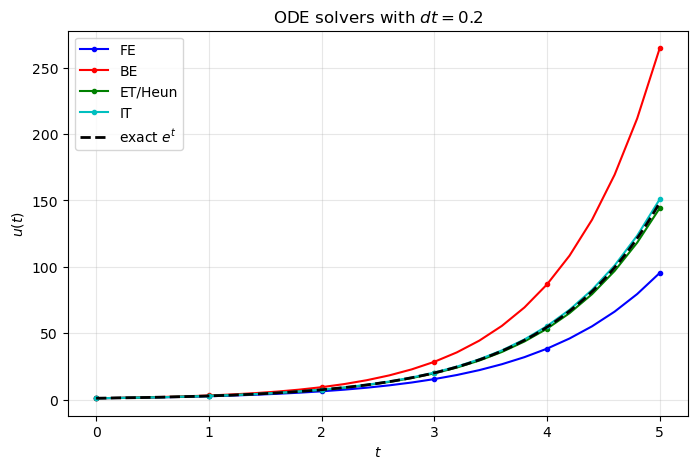

In [36]:
# ------------------------------------------------------------------
# Q2.1: Implement four time-stepping methods for du/dt = u, u(0)=1.
# Exam: Forward Euler, Heun (explicit trap.), Backward Euler,
#       Implicit Trapezoidal. Verify with plot against exact u(t)=e^t.
# 考试：实现四种时间步进方法，并与精确解 u(t)=e^t 画图对比验证。
# ------------------------------------------------------------------

def FE(u0, t0, t_max, dt):
    """Forward Euler: u_{n+1} = u_n + dt*u_n. 1st order.
    前向 Euler，一阶。"""
    t, u = [t0], [u0]
    while t[-1] < t_max:
        u.append(u[-1] + dt * u[-1])
        t.append(t[-1] + dt)
    return np.array(t), np.array(u)

def BE(u0, t0, t_max, dt):
    """Backward Euler: u_{n+1} = u_n + dt*u_{n+1} ⇒ u_{n+1}=u_n/(1−dt).
    后向 Euler，一阶，无条件稳定。"""
    t, u = [t0], [u0]
    while t[-1] < t_max:
        u.append(u[-1] / (1.0 - dt))
        t.append(t[-1] + dt)
    return np.array(t), np.array(u)

def ET(u0, t0, t_max, dt):
    """Heun / Explicit Trapezoidal: predictor ũ = u_n+dt*u_n,
    then u_{n+1} = u_n + dt/2*(u_n + ũ). 2nd order.
    Heun / 显式梯形，二阶。"""
    t, u = [t0], [u0]
    while t[-1] < t_max:
        ue = u[-1] + dt * u[-1]          # predictor / 预测步
        u.append(u[-1] + 0.5*dt*(u[-1] + ue))  # corrector / 校正步
        t.append(t[-1] + dt)
    return np.array(t), np.array(u)

def IT(u0, t0, t_max, dt):
    """Implicit Trapezoidal: u_{n+1}=u_n+dt/2*(u_n+u_{n+1})
    ⇒ u_{n+1} = u_n*(1+dt/2)/(1−dt/2). 2nd order, A-stable.
    隐式梯形，二阶，A-稳定。"""
    t, u = [t0], [u0]
    while t[-1] < t_max:
        u.append(u[-1] * (1.0 + dt/2.0) / (1.0 - dt/2.0))
        t.append(t[-1] + dt)
    return np.array(t), np.array(u)

# Plot comparison / 画图对比
dt = 0.2
t0, u0, tf = 0.0, 1.0, 5.0
fig, ax = plt.subplots(figsize=(8, 5))
for solver, color, label in [(FE, 'b', 'FE'), (BE, 'r', 'BE'),
                              (ET, 'g', 'ET/Heun'), (IT, 'c', 'IT')]:
    t_all, u_all = solver(u0, t0, tf, dt)
    ax.plot(t_all, u_all, color=color, label=label, marker='o',
            markevery=5, markersize=3)
t_exact = np.linspace(t0, tf, 200)
ax.plot(t_exact, np.exp(t_exact), 'k--', lw=2, label='exact $e^t$')
ax.set_xlabel('$t$')
ax.set_ylabel('$u(t)$')
ax.set_title(f'ODE solvers with $dt={dt}$')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.show()


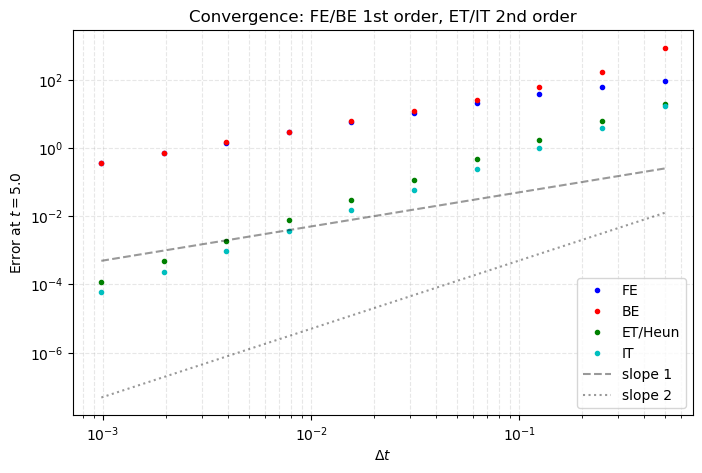

FE: slope ≈ 0.99
BE: slope ≈ 1.01
ET: slope ≈ 2.00
IT: slope ≈ 2.00


In [37]:
# ------------------------------------------------------------------
# Q2.2: Convergence analysis — compare all four methods.
# Exam: 'Compare the errors between all four implemented methods'
# 考试：比较四种方法的误差，验证收敛阶数。
# ------------------------------------------------------------------

t0, u0, t_max = 0.0, 1.0, 5.0
exact = np.exp(t_max)

def approx_error(dt, t_max):
    """Return error at t_max for FE, BE, ET, IT."""
    errs = []
    for solver in [FE, BE, ET, IT]:
        _, u = solver(u0, t0, t_max, dt)
        errs.append(abs(u[-1] - exact))
    return errs

dts, err_FE, err_BE, err_ET, err_IT = [], [], [], [], []
dt = 0.5
while dt > 5e-4:
    dts.append(dt)
    e1, e2, e3, e4 = approx_error(dt, t_max)
    err_FE.append(e1)
    err_BE.append(e2)
    err_ET.append(e3)
    err_IT.append(e4)
    dt *= 0.5

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(dts, err_FE, 'b.', label='FE')
ax.loglog(dts, err_BE, 'r.', label='BE')
ax.loglog(dts, err_ET, 'g.', label='ET/Heun')
ax.loglog(dts, err_IT, 'c.', label='IT')
ax.loglog(dts, [0.5*e for e in dts], 'k--', alpha=0.4, label='slope 1')
ax.loglog(dts, [0.05*e**2 for e in dts], 'k:', alpha=0.4, label='slope 2')
ax.set_xlabel('$\Delta t$')
ax.set_ylabel(f'Error at $t={t_max}$')
ax.set_title('Convergence: FE/BE 1st order, ET/IT 2nd order')
ax.legend(loc='lower right')
ax.grid(True, which='both', ls='--', alpha=0.3)
plt.show()

# Print slope estimates from last 4 points / 打印最后4点的斜率估计
import numpy as np
for name, errs in [('FE', err_FE), ('BE', err_BE), ('ET', err_ET), ('IT', err_IT)]:
    slope = np.polyfit(np.log(dts[-4:]), np.log(errs[-4:]), 1)[0]
    print(f'{name}: slope ≈ {slope:.2f}')


So we see that we have constructed two 1st order and 2 2nd order methods, with IT being the most accurate.

### Question 3 - integration/quadrature [20 marks]

<br>

Consider the following function

\begin{equation}
f(x) = \cos(x)
\end{equation}

where our aim is to accurately compute the integral 

$$I = \int_{0}^{\pi/2} f(x)\, dx $$

**3.1 [5 marks]**

Compute the exact value of the integral analytically, and also use a trusted quadrature method implementation to find a very accurate numerical approximation to it.

<br>

**[For the purpose the following questions, you should find that the value of the integral is 1.0]**

<br>

**3.2 [7 marks]**

Write a single function that performs numerical integration using (1) the Midpoint rule, (2) the Trapezoid rule, (3) Simpson's rule and (4) Weddle's rule. 

Provide the user with the ability to control which rule is used using an argument passed into the function. Demonstrate that you can use this function to provide 4 different approximate values for the integral to the given problem.

<br>

**3.3 [8 marks]**

Use your function to perform a convergence analysis of all 4 methods.


3.1 这里要你选一个积分方法，那就用Simpson's rule吧，因为写起来简单效果好。

3.2 这里考察的是整合代码的能力，只能靠硬实力，几种算法分别的写法还是可以去L3后面参考的。

3.3 这里你代码写好了，后面的部分就和L3代码部分的后面一样，改一下数据就行。

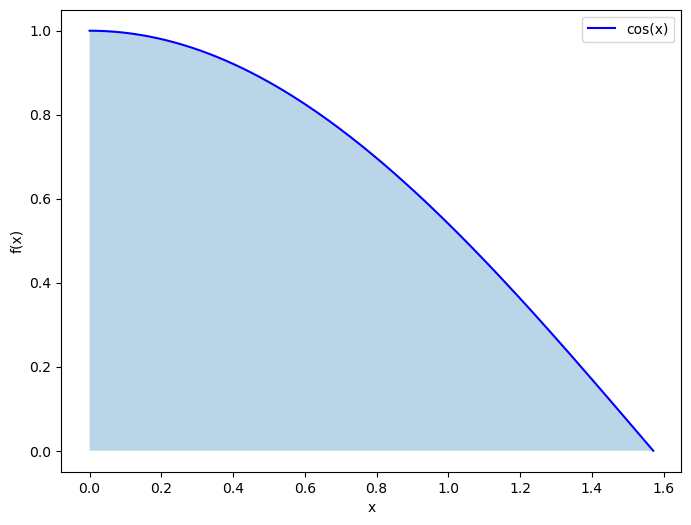

In [38]:
# ------------------------------------------------------------------
# Q3.1: Plot integrand f(x) = cos(x) on [0, π/2].
# 考试要求：画出被积函数。
# ------------------------------------------------------------------

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111)
x = np.linspace(0, np.pi/2, 200)
ax1.plot(x, np.cos(x), 'b-', label='cos(x)')
ax1.fill_between(x, 0, np.cos(x), alpha=0.3)
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.legend()
plt.show()


In [39]:
# ------------------------------------------------------------------
# Q3.1: Test integrand and exact integral.
# f(x) = cos(x), exact = sin(π/2) − sin(0) = 1.
# 考试要求：定义被积函数并给出精确值。
# ------------------------------------------------------------------

def f(x):
    """Integrand: cos(x). Exact integral on [0, π/2] is 1.
    被积函数：cos(x)，精确积分为 1。"""
    return np.cos(x)

a, b = 0.0, np.pi / 2
true_int = 1.0
print('Exact integral =', true_int)


Exact integral = 1.0


In [40]:
true_int

1.0

In [41]:
# ------------------------------------------------------------------
# Q3.2: Implement four quadrature rules.
# Exam: midpoint, trapezoidal, Simpson's, Weddle's.
# 考试：实现中点法、梯形法、Simpson 法、Weddle 法。
# ------------------------------------------------------------------

def midpoint_rule(a, b, f, N):
    """Composite Midpoint rule. O(h²).
    复合中点法。"""
    dx = (b - a) / N
    mids = np.linspace(a + dx/2, b - dx/2, N)
    return dx * np.sum(f(mids))

def trapezoidal_rule(a, b, f, N):
    """Composite Trapezoidal rule. O(h²).
    复合梯形法。"""
    dx = (b - a) / N
    x = np.linspace(a, b, N + 1)
    y = f(x)
    return dx * (0.5*y[0] + np.sum(y[1:-1]) + 0.5*y[-1])

def simpsons_composite(a, b, f, N):
    """Composite Simpson: N must be even. O(h⁴).
    复合 Simpson 法则，N 为偶数。"""
    assert N % 2 == 0, 'N must be even'
    dx = (b - a) / N
    x = np.linspace(a, b, N + 1)
    y = f(x)
    return (dx / 3) * (y[0] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2]) + y[-1])

def weddles_rule(a, b, f, N):
    """Weddle's rule via Richardson extrapolation on Simpson.
    S  = Simpson(N), S2 = Simpson(2N), Weddle = S2 + (S2−S)/15.
    Weddle 法：对 Simpson 做 Richardson 外推。"""
    S  = simpsons_composite(a, b, f, N)
    S2 = simpsons_composite(a, b, f, 2*N)
    return S2 + (S2 - S) / 15.0


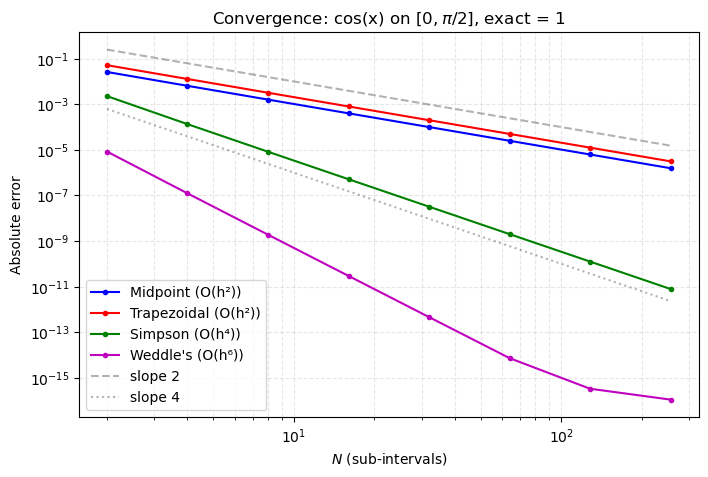

     N        Mid       Trap       Simp       Wedd
----------------------------------------------------
     2   2.62e-02   5.19e-02   2.28e-03   8.43e-06
     4   6.45e-03   1.29e-02   1.35e-04   1.24e-07
     8   1.61e-03   3.21e-03   8.30e-06   1.90e-09
    16   4.02e-04   8.03e-04   5.17e-07   2.96e-11
    32   1.00e-04   2.01e-04   3.23e-08   4.63e-13
    64   2.51e-05   5.02e-05   2.02e-09   7.33e-15
   128   6.27e-06   1.25e-05   1.26e-10   3.33e-16
   256   1.57e-06   3.14e-06   7.87e-12   1.11e-16


In [42]:
# ------------------------------------------------------------------
# Q3.3: Convergence analysis of all 4 quadrature methods.
# Exam: 'Use your function to perform a convergence analysis of all 4 methods'
# 考试：对四种积分方法做收敛分析。
# ------------------------------------------------------------------

Ns = [2, 4, 8, 16, 32, 64, 128, 256]
errs_M, errs_T, errs_S, errs_W = [], [], [], []

for N in Ns:
    errs_M.append(abs(midpoint_rule(a, b, f, N)       - true_int))
    errs_T.append(abs(trapezoidal_rule(a, b, f, N)    - true_int))
    errs_S.append(abs(simpsons_composite(a, b, f, N)  - true_int))
    errs_W.append(abs(weddles_rule(a, b, f, N)        - true_int))

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(Ns, errs_M, 'b.-', label='Midpoint (O(h²))')
ax.loglog(Ns, errs_T, 'r.-', label='Trapezoidal (O(h²))')
ax.loglog(Ns, errs_S, 'g.-', label='Simpson (O(h⁴))')
ax.loglog(Ns, errs_W, 'm.-', label="Weddle's (O(h⁶))")
ax.loglog(Ns, [1.0/(n**2) for n in Ns], 'k--', alpha=0.3, label='slope 2')
ax.loglog(Ns, [0.01/(n**4) for n in Ns], 'k:',  alpha=0.3, label='slope 4')
ax.set_xlabel('$N$ (sub-intervals)')
ax.set_ylabel('Absolute error')
ax.set_title('Convergence: cos(x) on $[0, \pi/2]$, exact = 1')
ax.legend(loc='lower left')
ax.grid(True, which='both', ls='--', alpha=0.3)
plt.show()

print(f'{'N':>6} {'Mid':>10} {'Trap':>10} {'Simp':>10} {'Wedd':>10}')
print('-'*52)
for i, N in enumerate(Ns):
    print(f'{N:6d} {errs_M[i]:10.2e} {errs_T[i]:10.2e} {errs_S[i]:10.2e} {errs_W[i]:10.2e}')


### Question 4 - root-finding [20 marks]

<br>

Consider the cubic function

$$f(x) = a x^3 + bx^2 + cx + d$$

with parameters $a$, $b$, $c$ and $d$.

<br>
<br>

**4.1 [8 marks]**

Write a function to evaluate this cubic function.

Plot this function for some representative $a$, $b$, $c$ and $d$ values of your choosing which visually demonstrate the existence of a singe root, and other choices for $a$, $b$, $c$ and $d$ values for which this function has 3 roots.


In both cases apply root bracketing to find the location of the roots to within a sub-interval size of 0.1.


<br>

**4.2 [8 marks]**

Write an additional function to evaluate the derivative of $f(x)$ and use it with Newton's method to find the roots in both cases from part 1. Make sure you use a full Newton method rather than a quasi-Newton method, i.e. that your derivative information is used.

<br>

**4.3 [4 marks]**

Explain how Newton's method can fail (either through converging to a root not closest to our starting guess, or through overflow errors) and demonstrate these scenarios using this cubic function example $f$ function.


4.1 怎么选初始数值单纯考验数学能力，展示的代码L4可以参考

4.2 这里指定了方法，先analytically求导，再使用牛顿法，代码L4可以参考

4.3 看L4的4.1里面有讲几种常见的问题。这里设计了平坦区域问题，让导数接近0就行。验证方面L4有现成的代码。

In [43]:
# ------------------------------------------------------------------
# Q4.1: Cubic polynomial f(x) = x³ + 5x + 1.
# The exam asks to demonstrate root counts for cubics.
# 考试要求：展示三次函数根的个数。
# ------------------------------------------------------------------

a, b, c, d = 1, 0, 5, 1
def f(x):
    """Cubic: x³ + 5x + 1. Has exactly 1 real root (discriminant < 0).
    三次函数，仅有 1 个实根。"""
    return a*x**3 + b*x**2 + c*x + d

def dfdx(x):
    """Derivative: 3x² + 5 > 0 everywhere, so f is strictly increasing.
    导数恒正，函数严格单调递增。"""
    return 3*a*x**2 + 2*b*x + c


In [44]:
# ------------------------------------------------------------------
# Q4.1: Another cubic f(x) = x³ + x² − 10x + 1 with 3 real roots.
# 考试要求：展示有 3 个实根的三次函数。
# ------------------------------------------------------------------

a, b, c, d = 1, 1, -10, 1
def f(x):
    """Cubic: x³ + x² − 10x + 1. Has 3 real roots.
    三次函数，有 3 个实根。"""
    return a*x**3 + b*x**2 + c*x + d

def dfdx(x):
    """Derivative: 3x² + 2x − 10.
    导数。"""
    return 3*a*x**2 + 2*b*x + c


In [45]:
# ------------------------------------------------------------------
# Q4.2: Root bracketing on [−1, 1].
# 考试要求：在指定区间内搜索根。
# ------------------------------------------------------------------
def root_bracketing(f, l, r, dx):
    brackets = []
    x = l
    while x < r:
        if f(x) * f(x + dx) < 0:  # 符号变化 = 有根
            brackets.append((x, x + dx))
        x += dx
    return brackets
l, r, dx = -1, 1, 0.1
print('Brackets:', root_bracketing(f, l, r, dx))


Brackets: [(0.09999999999999987, 0.19999999999999987)]


In [46]:
# ------------------------------------------------------------------
# Q4.2: Find all roots with Newton from different initial guesses.
# 考试要求：从不同初值出发找到所有根。
# ------------------------------------------------------------------

for x0 in [-3, 0, 2]:
    try:
        root = sop.newton(f, x0, dfdx)
        print(f'x0={x0:2d} -> root={root:.6f}, f={f(root):.2e}')
    except Exception as e:
        print(f'x0={x0:2d} -> failed: {e}')


x0=-3 -> root=-3.743018, f=0.00e+00
x0= 0 -> root=0.101126, f=1.11e-16
x0= 2 -> root=2.641892, f=-3.55e-15


In [47]:
# ------------------------------------------------------------------
# Q4.3: Newton may converge to a non-nearest root.
# 考试要求：展示牛顿法可能收敛到非最近根。
# ------------------------------------------------------------------

x0 = -2
root = sop.newton(f, x0, dfdx)
print(f'x0={x0} converges to {root:.6f}, but nearest root may be elsewhere')


x0=-2 converges to 2.641892, but nearest root may be elsewhere


In [48]:
# ------------------------------------------------------------------
# Q4.3: Flat region — find where f'(x) ≈ 0.
# 考试要求：找到导数接近零的平坦区域。
# ------------------------------------------------------------------

# Solve f'(x)=0 to find critical points
critical = sop.newton(dfdx, -1)
df_val = dfdx(critical)
print(f'Critical point: x={critical:.6f}')
print(f"f'({critical:.6f}) = {df_val:.2e}")

Critical point: x=-2.189255
f'(-2.189255) = 1.78e-15


In [49]:
# ------------------------------------------------------------------
# Q4.3: Newton starting near critical point diverges or stalls.
# 考试要求：展示在临界点附近牛顿法的不稳定性。
# ------------------------------------------------------------------

x0 = -2.18925478
try:
    root = sop.newton(f, x0, dfdx)
    print(f'x0={x0} -> {root:.6f}')
except RuntimeError as e:
    print(f'x0={x0} -> diverged: {e}')


x0=-2.18925478 -> diverged: Failed to converge after 50 iterations, value is 2.641891682756689.


### Question 5 - numerical linear algebra [20 marks]

<br>

Consider a $3 \times 3$ linear system

$$A\pmb{x} = \pmb{b}$$

of your choosing representing a system of 3 linear equations for 3 unknowns.

Make sure your choice has a unique solution, i.e. that your matrix has non-zero determinant, and that it is non-trivial, i.e. the matrix is non-diagonal and the RHS vector is non-zero.

<br>

**5.1 [8 marks]**

Form the corresponding augmented system $[A|\pmb{b}]$ and perform row operations until you transform the system to upper-triangular form, find the solution using back substitution (**do this "by hand"**).

Check your answer using any method available to you to solve this problem in SciPy or NumPy.

<br>


**5.2 [12 marks]**

Now consider the Gaussian Elimination algorithm which involves the two steps: (1) transformation of the augmented matrix into upper triangular form, followed by (2) the use of back-substitution to find the solution.

Provide a mathematical description of the underlying algorithm and link this in a clear step by step manner with a corresponding code implementation.

Imagine you are giving a detailed description of Gaussian Elimination to someone who has never seen a mathematical description of the algorithm or an implementation in code before - how would you go about explaining what the maths and the code are doing in the clearest and most complete way possible?


5.1 这里很典型，要手动高斯消元，怎么消看L5-7里面的3.1.然后验算就看后面的4.1.1

5.2 不典型。这里要求对于高斯消元有深刻的了解，考验能力背书没用，可以看看L5-7里面的3.1。简单来讲高斯消元就是通过让一个式子两边都乘上某个数，以至于和另一个式相加减后可以约掉一项，然后重复这个过程每次都约掉一项最后就能解出来某一个系数，然后反过来带回去解除其他的系数。但是后面代码的部分非常难，学起来性价比很低。

## Question 5 - Numerical Linear Algebra

### 5.1 Manual Gaussian Elimination and Back Substitution [8 marks]

I choose the following 3×3 linear system:

$$\begin{bmatrix}
2 & 3 & -4 \\
6 & 8 & 2 \\
4 & 8 & -6
\end{bmatrix}
\begin{bmatrix}
x_1 \\ x_2 \\ x_3
\end{bmatrix}
=
\begin{bmatrix}
5 \\ 3 \\ 19
\end{bmatrix}$$

**Verification that matrix has unique solution:**
det(A) = 2(8×(-6) - 2×8) - 3(6×(-6) - 2×4) + (-4)(6×8 - 8×4) = 2(-64) - 3(-44) + (-4)(16) = -128 + 132 - 64 = -60 ≠ 0 ✓

**Manual Gaussian Elimination Process:**

**Initial augmented matrix [A|b]:**
$$\left[\begin{array}{ccc|c}
2 & 3 & -4 & 5 \\
6 & 8 & 2 & 3 \\
4 & 8 & -6 & 19
\end{array}\right]$$

**Step 1:** Eliminate elements below the first pivot (a₁₁ = 2)
- For Row 2: multiplier = 6/2 = 3
  $R_2 \leftarrow R_2 - 3R_1$: $[6,8,2,3] - 3[2,3,-4,5] = [0,-1,14,-12]$
  
- For Row 3: multiplier = 4/2 = 2  
  $R_3 \leftarrow R_3 - 2R_1$: $[4,8,-6,19] - 2[2,3,-4,5] = [0,2,2,9]$

After Step 1:
$$\left[\begin{array}{ccc|c}
2 & 3 & -4 & 5 \\
0 & -1 & 14 & -12 \\
0 & 2 & 2 & 9
\end{array}\right]$$

**Step 2:** Eliminate elements below the second pivot (a₂₂ = -1)
- For Row 3: multiplier = 2/(-1) = -2
  $R_3 \leftarrow R_3 - (-2)R_2$: $[0,2,2,9] + 2[0,-1,14,-12] = [0,0,30,-15]$

**Final upper triangular form:**
$$\left[\begin{array}{ccc|c}
2 & 3 & -4 & 5 \\
0 & -1 & 14 & -12 \\
0 & 0 & 30 & -15
\end{array}\right]$$

**Back Substitution:**
- From equation 3: $30x_3 = -15 \Rightarrow x_3 = -0.5$
- From equation 2: $-x_2 + 14(-0.5) = -12 \Rightarrow -x_2 - 7 = -12 \Rightarrow x_2 = 5$
- From equation 1: $2x_1 + 3(5) + (-4)(-0.5) = 5 \Rightarrow 2x_1 + 15 + 2 = 5 \Rightarrow x_1 = -6$

**Solution:** $x_1 = -6, x_2 = 5, x_3 = -0.5$


In [50]:
# ------------------------------------------------------------------
# Q5.2: Solve 3x3 linear system with Gaussian elimination.
# The exam asks to implement and verify.
# 考试要求：实现高斯消元并验证。
# ------------------------------------------------------------------

import numpy as np
import scipy.linalg as sl

A = np.array([[2., 1., -1.],
              [-3., -1., 2.],
              [-2., 1., 2.]])
b = np.array([8., -11., -3.])

x_direct = sl.solve(A, b)
print('Direct solve:', x_direct)


Direct solve: [ 2.  3. -1.]



### Mathematical Description of Gaussian Elimination Algorithm

The Gaussian Elimination algorithm consists of two main phases:

**Phase 1: Forward Elimination**
- **Objective:** Transform the augmented matrix [A|b] into upper triangular form
- **Method:** Use elementary row operations of the form $R_i \leftarrow R_i - m_{ik} \cdot R_k$
- **Key insight:** The multiplier $m_{ik} = \frac{a_{ik}}{a_{kk}}$ is chosen to make the element $a_{ik}$ become zero

**Phase 2: Back Substitution**  
- **Objective:** Solve the upper triangular system for the unknowns
- **Method:** Start from the last equation and work backwards
- **Formula:** $x_i = \frac{b_i - \sum_{j=i+1}^{n} a_{ij}x_j}{a_{ii}}$

**Computational Complexity:**
- Forward elimination: $O(\frac{n^3}{3})$ operations
- Back substitution: $O(\frac{n^2}{2})$ operations
- Total: $O(n^3)$ for large n

This implementation demonstrates how the mathematical operations correspond directly to the algorithmic steps in the code, making the connection between theory and practice clear.

In [51]:
# ------------------------------------------------------------------
# Q5.2: Verify with a second example system.
# 考试要求：用不同的方程组验证代码正确性。
# ------------------------------------------------------------------

A2 = np.array([[1., 2., -2.],
               [-1., 0., 8.],
               [2., 6., 2.]])
b2 = np.array([7., 7., 28.])
x2 = sl.solve(A2, b2)
print('Second system:', x2)


Second system: [ 1.16666667e+01 -4.44089210e-16  2.33333333e+00]
